<a href="https://colab.research.google.com/github/Nguyen-Quoc-An/TH_DeepLearning/blob/main/LAB2_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANN


In [ ]:
pip install scikeras

In [ ]:
#install required libraries
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
mimax = MinMaxScaler()
X_train = mimax.fit_transform(X_train)
X_test = mimax.transform(X_test)

print('Số lớp:',len(np.unique(y_train)))
print('Lớp:',np.unique(y_train))


Số lớp: 10
Lớp: [0 1 2 3 4 5 6 7 8 9]


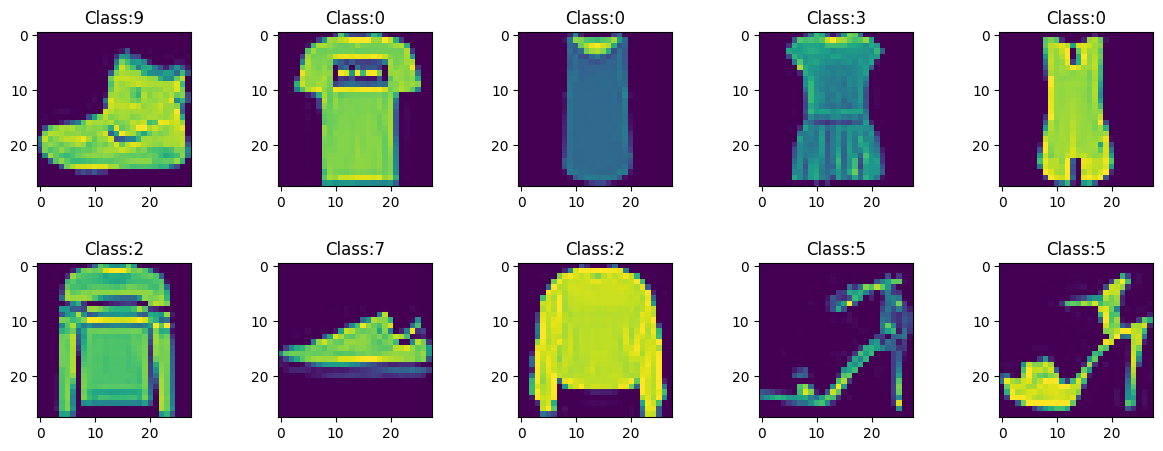

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [19]:
fashion_model = Sequential()
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8191 - loss: 0.5053 - val_accuracy: 0.8513 - val_loss: 0.4194
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8634 - loss: 0.3729 - val_accuracy: 0.8657 - val_loss: 0.3704
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8788 - loss: 0.3330 - val_accuracy: 0.8692 - val_loss: 0.3560
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8873 - loss: 0.3069 - val_accuracy: 0.8690 - val_loss: 0.3597
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8944 - loss: 0.2881 - val_accuracy: 0.8810 - val_loss: 0.3310
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8995 - loss: 0.2723 - val_accuracy: 0.8845 - val_loss: 0.3247
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9025 - loss: 0.2604 - val_accuracy: 0.8767 - val_loss: 0.3556
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9077 - loss:

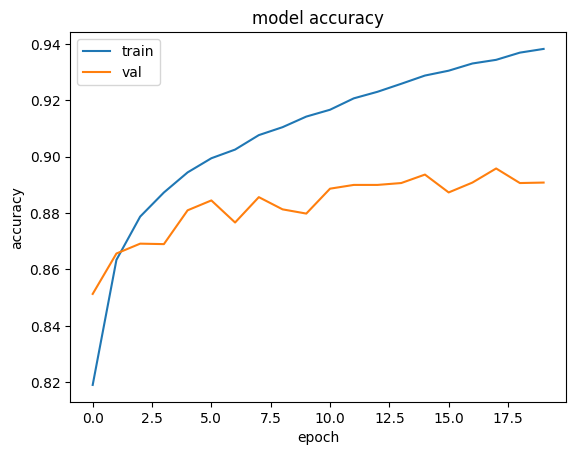

In [21]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

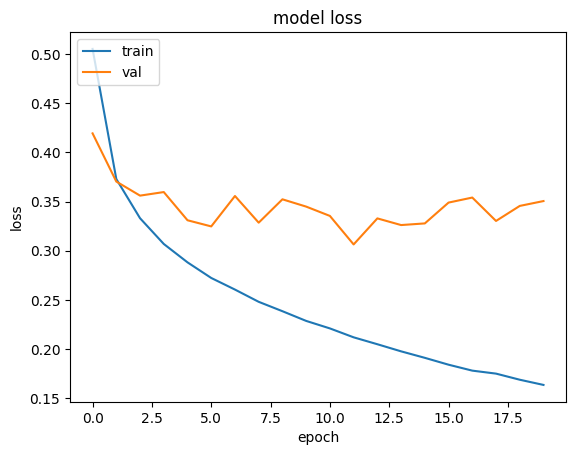

In [22]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [23]:
print(np.argmax(fashion_model.predict(X_test)[0]),y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]),y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   label  pixel1  pixel2  pixel3  ...  pixel781  pixel782  pixel783  pixel784
0      2       0       0       0  ...         0         0         0         0
1      9       0       0       0  ...         0         0         0         0
2      6       0       0       0  ...         0         0         0         0
3      0       0       0       0  ...         0         0         0         0
4      3       0       0       0  ...         0         0         0         0

[5 rows x 785 columns]
(60000, 785)


In [49]:
X_train = mnist_train.iloc[:,1:] / 255.0
X_test = mnist_test.iloc[:,1:] / 255.0
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))


(60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [50]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model_fit = model.fit(X_train, y_train,epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8198 - loss: 0.5011
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8637 - loss: 0.3706
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8770 - loss: 0.3333
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8860 - loss: 0.3085
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8930 - loss: 0.2921
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8976 - loss: 0.2776
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9023 - loss: 0.2625
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9064 - loss: 0.2521
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9109 - loss: 0.2412
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9128 - loss: 0.2326
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9164 - loss: 0.2231
Epoch 12/30
1875/18

In [52]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0 0


In [54]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
8


#REGRESSION


In [13]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

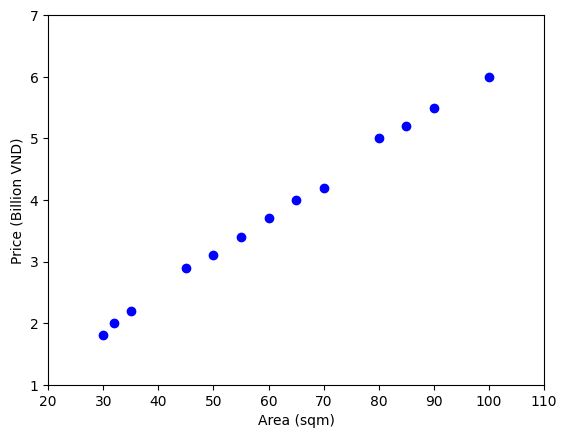

In [14]:
# Area (m^2)
X = np.array([[30, 32, 35, 45, 50, 55, 60, 65, 70, 80, 85, 90, 100]]).T

# Price (Billion VND)
y = np.array([[1.8, 2.0, 2.2, 2.9, 3.1, 3.4, 3.7, 4.0, 4.2, 5.0, 5.2, 5.5, 6.0]]).T

# Visualize data
plt.plot(X, y, 'bo') # Dùng điểm màu xanh dương (blue)
plt.axis([20, 110, 1, 7])
plt.xlabel('Area (sqm)')
plt.ylabel('Price (Billion VND)')
plt.show()

w =  [[0.09840569]
 [0.05987544]]


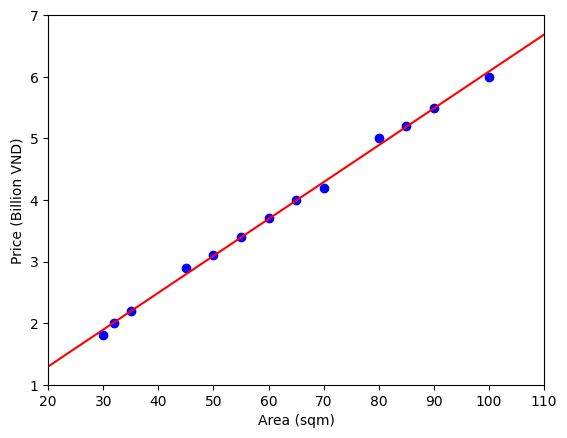

In [16]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)

# Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(20, 110, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, y.T, 'bo')     # data
plt.plot(x0, y0, 'r-')       # the fitting line (đường màu đỏ)
plt.axis([20, 110, 1, 7])
plt.xlabel('Area (sqm)')
plt.ylabel('Price (Billion VND)')
plt.show()

In [17]:
y1 = w_1*40 + w_0
y2 = w_1*75 + w_0

print('Predict price of 40 sqm house: %.2f (Billion), real number: 2.50 (Billion)' %(y1))
print('Predict price of 75 sqm house: %.2f (Billion), real number: 4.50 (Billion)' %(y2))

Predict price of 40 sqm house: 2.49 (Billion), real number: 2.50 (Billion)
Predict price of 75 sqm house: 4.59 (Billion), real number: 4.50 (Billion)


In [18]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, y)

# Compare two results
print('Solution found by scikit-learn  : ', regr.coef_ )
print('Solution found by formula       : ', w.T)

Solution found by scikit-learn  :  [[0.09840569 0.05987544]]
Solution found by formula       :  [[0.09840569 0.05987544]]


# BÀI TẬP ANN


In [55]:
#1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Tải bộ dữ liệu CIFAR10 có sẵn từ TensorFlow
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Chuẩn hóa dữ liệu ảnh (Scale pixel values)
# Đưa giá trị pixel từ khoảng [0, 255] về khoảng [0, 1] để mô hình học tốt hơn
x_train = x_train / 255.0
x_test = x_test / 255.0

# Khai báo các nhãn (labels) tương ứng với bảng mô tả trong đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Khởi tạo mô hình ANN (Mạng nơ-ron nhân tạo kết nối đầy đủ - Fully Connected)
model = tf.keras.Sequential([
    # Bước 3.1: Chuyển đổi ma trận ảnh 3D (32x32x3) thành vector 1D (3072 phần tử)
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),

    # Bước 3.2: Các lớp ẩn (Hidden Layers)
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    # Bước 3.3: Lớp đầu ra (Output Layer) với 10 nơ-ron tương ứng 10 nhãn
    # Sử dụng hàm Softmax để tính xác suất cho từng lớp
    tf.keras.layers.Dense(10, activation='softmax')
])

# 4. Biên dịch mô hình (Compile model)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Hiển thị cấu trúc của mô hình
model.summary()

# 5. Huấn luyện mô hình (Training)
print("\nĐang tiến hành huấn luyện mô hình...")
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# 6. Đánh giá mô hình trên tập test (Evaluation)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm thử (Test Accuracy): {test_acc:.4f}')

# ==========================================
# (Tùy chọn) Code test thử dự đoán 1 ảnh
# ==========================================
image_index = 0 # Chọn ảnh đầu tiên trong tập test
predictions = model.predict(x_test[image_index:image_index+1])
predicted_label = np.argmax(predictions[0])
true_label = y_test[image_index][0]

print(f"\n--- Kết quả dự đoán thử ảnh index {image_index} ---")
print(f"Nhãn dự đoán: {class_names[predicted_label]} (Label {predicted_label})")
print(f"Nhãn thực tế: {class_names[true_label]} (Label {true_label})")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


Đang tiến hành huấn luyện mô hình...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 33ms/step - accuracy: 0.3224 - loss: 1.8646 - val_accuracy: 0.3561 - val_loss: 1.7880
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.3930 - loss: 1.6844 - val_accuracy: 0.4002 - val_loss: 1.6588
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 29ms/step - accuracy: 0.4293 - loss: 1.5998 - val_accuracy: 0.4201 - val_loss: 1.6234
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.4477 - loss: 1.5418 - val_accuracy: 0.4349 - val_loss: 1.5638
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4609 - loss: 1.5005 - val_accuracy: 0.4601 - val_loss: 1.5248
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.4728 - loss: 1.4699 - val_accuracy: 0.4475 - val_loss: 1.5451
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.4831 - loss: 1.4400 - val_accuracy: 0.4732 - val_loss: 1.4788
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━

In [56]:
#2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên cung cấp với các nhãn sau
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Tải bộ dữ liệu
# ==========================================
# Sử dụng bộ dataset MNIST chuẩn từ Keras.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# ==========================================
# 2. Tiền xử lý dữ liệu
# ==========================================
# Ảnh MNIST là ảnh đa cấp xám (grayscale), giá trị pixel từ 0 - 255.
# Chuẩn hóa về khoảng [0, 1] để mạng nơ-ron học tốt hơn.
x_train = x_train / 255.0
x_test = x_test / 255.0

# Khai báo mảng nhãn tương ứng với bảng của đề bài
class_names = ['Số 0', 'Số 1', 'Số 2', 'Số 3', 'Số 4',
               'Số 5', 'Số 6', 'Số 7', 'Số 8', 'Số 9']

# ==========================================
# 3. Xây dựng cấu trúc mạng ANN
# ==========================================
model = tf.keras.Sequential([
    # Input layer: Ảnh MNIST có kích thước 28x28 (ảnh xám, không có kênh màu).
    # Hàm Flatten sẽ duỗi ma trận 2D này thành một vector 1D chứa 784 phần tử (28 * 28).
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden layers: Có thể tùy chỉnh số lượng nơ-ron. Ở đây dùng 2 lớp ẩn.
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),

    # Output layer: Bắt buộc là 10 nơ-ron (tương ứng 10 chữ số từ 0-9) và dùng softmax
    tf.keras.layers.Dense(10, activation='softmax')
])

# ==========================================
# 4. Biên dịch mô hình
# ==========================================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Xem tóm tắt kiến trúc mạng
model.summary()

# ==========================================
# 5. Huấn luyện mô hình
# ==========================================
print("\n--- Bắt đầu huấn luyện mô hình ANN trên tập MNIST ---")
# Epochs là số lần duyệt qua toàn bộ tập dữ liệu huấn luyện
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# ==========================================
# 6. Đánh giá kết quả
# ==========================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm thử (Test Accuracy): {test_acc:.4f}')

# ==========================================
# (Tùy chọn) Kiểm tra trực quan 1 dự đoán
# ==========================================
image_index = 100 # Chọn một ảnh bất kỳ trong tập test để thử
prediction = model.predict(x_test[image_index:image_index+1])
predicted_label = np.argmax(prediction[0])
true_label = y_test[image_index]

print(f"\nNhãn dự đoán: {class_names[predicted_label]}")
print(f"Nhãn thực tế: {class_names[true_label]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ANN trên tập MNIST ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9280 - loss: 0.2449 - val_accuracy: 0.9617 - val_loss: 0.1219
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9689 - loss: 0.1031 - val_accuracy: 0.9707 - val_loss: 0.0998
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9774 - loss: 0.0724 - val_accuracy: 0.9740 - val_loss: 0.0868
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9823 - loss: 0.0549 - val_accuracy: 0.9706 - val_loss: 0.0932
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9865 - loss: 0.0425 - val_accuracy: 0.9769 - val_loss: 0.0763
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9888 - loss: 0.0342 - val_accuracy: 0.9768 - val_loss: 0.0767
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9907 - loss: 0.0289 - val_accuracy: 0.9790 - val_loss: 0.0777
Epoch 8/10
1875/1875 ━━━━━━━

In [57]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Tải dữ liệu đã lưu từ bước trước
# ==========================================
print("Đang tải dữ liệu từ file .npy...")
photos = np.load('dogs_vs_cats_photos.npy')
labels = np.load('dogs_vs_cats_labels.npy')

# ==========================================
# 2. Tiền xử lý dữ liệu
# ==========================================
# Chuẩn hóa giá trị pixel từ [0, 255] về khoảng [0, 1]
photos = photos.astype('float32') / 255.0

# Chia tập dữ liệu thành tập huấn luyện (80%) và tập kiểm tra (20%)
x_train, x_test, y_train, y_test = train_test_split(photos, labels, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {x_train.shape}")
print(f"Kích thước tập kiểm tra: {x_test.shape}")

# ==========================================
# 3. Xây dựng mô hình ANN
# ==========================================
model = tf.keras.Sequential([
    # Input layer: Ảnh có kích thước 200x200 và 3 kênh màu (RGB).
    # Lớp Flatten sẽ chuyển ma trận 3D này thành 1 vector 1D (200 * 200 * 3 = 120,000 chiều)
    tf.keras.layers.Flatten(input_shape=(200, 200, 3)),

    # Hidden layers: Có thể giảm số nơ-ron nếu máy tính bị thiếu RAM
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer: Bài toán phân loại nhị phân (Cat=0, Dog=1)
    # Chỉ cần 1 nơ-ron ở lớp cuối cùng kết hợp với hàm kích hoạt Sigmoid
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ==========================================
# 4. Biên dịch mô hình
# ==========================================
# Hàm mất mát phải đổi thành 'binary_crossentropy' do đây là phân loại nhị phân
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 5. Huấn luyện mô hình
# ==========================================
print("\n--- Bắt đầu huấn luyện mô hình ---")
# Sử dụng batch_size để chia nhỏ dữ liệu đưa vào RAM mỗi bước học
history = model.fit(x_train, y_train, epochs=15, batch_size=32, validation_data=(x_test, y_test))

# ==========================================
# 6. Đánh giá kết quả
# ==========================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'\nĐộ chính xác trên tập kiểm thử (Test Accuracy): {test_acc * 100:.2f}%')

Đang tải dữ liệu từ file .npy...


FileNotFoundError: [Errno 2] No such file or directory: 'dogs_vs_cats_photos.npy'